In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.linalg import eigh

In [2]:
# load data (you'll find the distances.csv file on Moodle)
distances = pd.read_csv('distances.csv', index_col='cities')
distances

,"Youngstown, OH","Yankton, SD","Yakima, WA","Worcester, MA","Wisconsin Dells, WI","Winston-Salem, NC","Winnipeg, MB","Winchester, VA","Wilmington, NC","Wilmington, DE",...,"Roanoke, VA","Richmond, VA","Richmond, IN","Richfield, UT","Rhinelander, WI","Reno, NV","Regina, SA","Red Bluff, CA","Reading, PA","Ravenna, OH"
cities,,,,,,,,,,,,,,,,,,,,,
"Youngstown, OH",0.000,1.163,2.780,0.616,0.653,0.346,1.291,0.216,0.510,0.364,...,0.269,0.330,0.305,2.178,0.682,2.707,1.778,2.874,0.330,0.040
"Yankton, SD",1.163,0.000,1.618,1.768,0.529,1.273,0.483,1.352,1.471,1.524,...,1.266,1.426,0.889,1.054,0.582,1.566,0.723,1.727,1.493,1.122
"Yakima, WA",2.780,1.618,0.000,3.378,2.133,2.874,1.629,2.970,3.064,3.142,...,2.876,3.040,2.505,0.794,2.149,0.491,1.127,0.459,3.110,2.739
"Worcester, MA",0.616,1.768,3.378,0.000,1.245,0.722,1.828,0.488,0.697,0.312,...,0.660,0.509,0.920,2.794,1.239,3.322,2.338,3.488,0.315,0.656
"Wisconsin Dells, WI",0.653,0.529,2.133,1.245,0.000,0.838,0.668,0.858,1.044,1.018,...,0.808,0.949,0.427,1.578,0.140,2.094,1.130,2.256,0.983,0.613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Reno, NV",2.707,1.566,0.491,3.322,2.094,2.743,1.721,2.877,2.917,3.058,...,2.759,2.930,2.412,0.535,2.141,0.000,1.290,0.173,3.032,2.667
"Regina, SA",1.778,0.723,1.127,2.338,1.130,1.954,0.519,1.988,2.158,2.141,...,1.934,2.079,1.549,0.955,1.102,1.290,0.000,1.406,2.103,1.739
"Red Bluff, CA",2.874,1.727,0.459,3.488,2.256,2.914,1.858,3.046,3.089,3.226,...,2.929,3.100,2.580,0.708,2.298,0.173,1.406,0.000,3.199,2.833


This data describes the distance (in thousands of miles) between 57 North American cities.
Your **goal** is to use Multidimensional Scaling to reconstruct the positions of these cities.

**Remark:** If you want to reconstruct a rough map of North America from these distances, you may need to rotate the reconstructed positions and/or swap the rows of the reconstructed positions. 

In [6]:
#Euclidean distance Matrix
D=distances.values**2

In [7]:
#Solve for G
n = D.shape[0]
G = 0.5*(np.ones((n,1)).dot(D[[0],:]) + D[:,[0]].dot(np.ones((1,n))) - D)

In [9]:
# the two eigenvectors with the largest eigenvalues
D,Q = eigh(G, subset_by_index=[n-2,n-1])

In [10]:
D

array([ 17.95012723, 249.48835463])

In [11]:
X = (Q*np.sqrt(D)).T
X[[0,1]] = X[[1,0]]

In [13]:
names = distances.index.to_list()

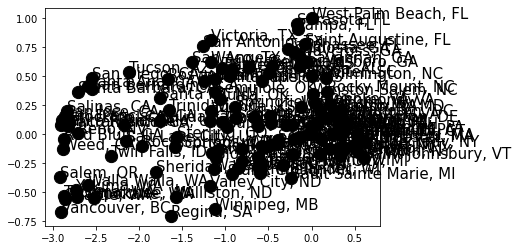

In [15]:
#plot recovered positions
plt.scatter(X[0],X[1],color='black', s=150)

for i in range(n):
    plt.annotate(text=names[i],
                xy=(X[0,i], X[1,i]),
                 fontsize = 15
                )

This map seems to be upside-down! Lets try and flip it over the line y=0 and see if that helps us recover a more recognizable shape

In [17]:
rot = np.array([[1,0],[0,-1]])

X = rot.dot(X)

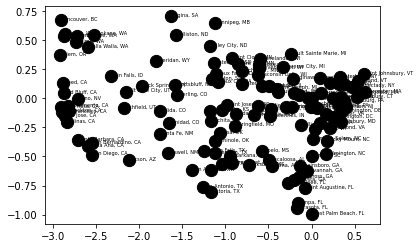

In [21]:
#plot recovered positions (and also adjust the font size)
plt.scatter(X[0],X[1],color='black', s=150)

for i in range(n):
    plt.annotate(text=names[i],
                xy=(X[0,i], X[1,i]),
                 fontsize = 5
                )